# **Necessary Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
%matplotlib inline

# **Exploratory Data Analysis (EDA)**

In [2]:
df = pd.read_csv('telco-customer-churn.csv')

In [3]:
# Check for all the columns
columns = list(df.columns)
columns

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check the dataframe's dimensions
df.shape

(7043, 21)

In [7]:
list(df['gender'].unique())

['Female', 'Male']

In [8]:
list(df['InternetService'].unique())

['DSL', 'Fiber optic', 'No']

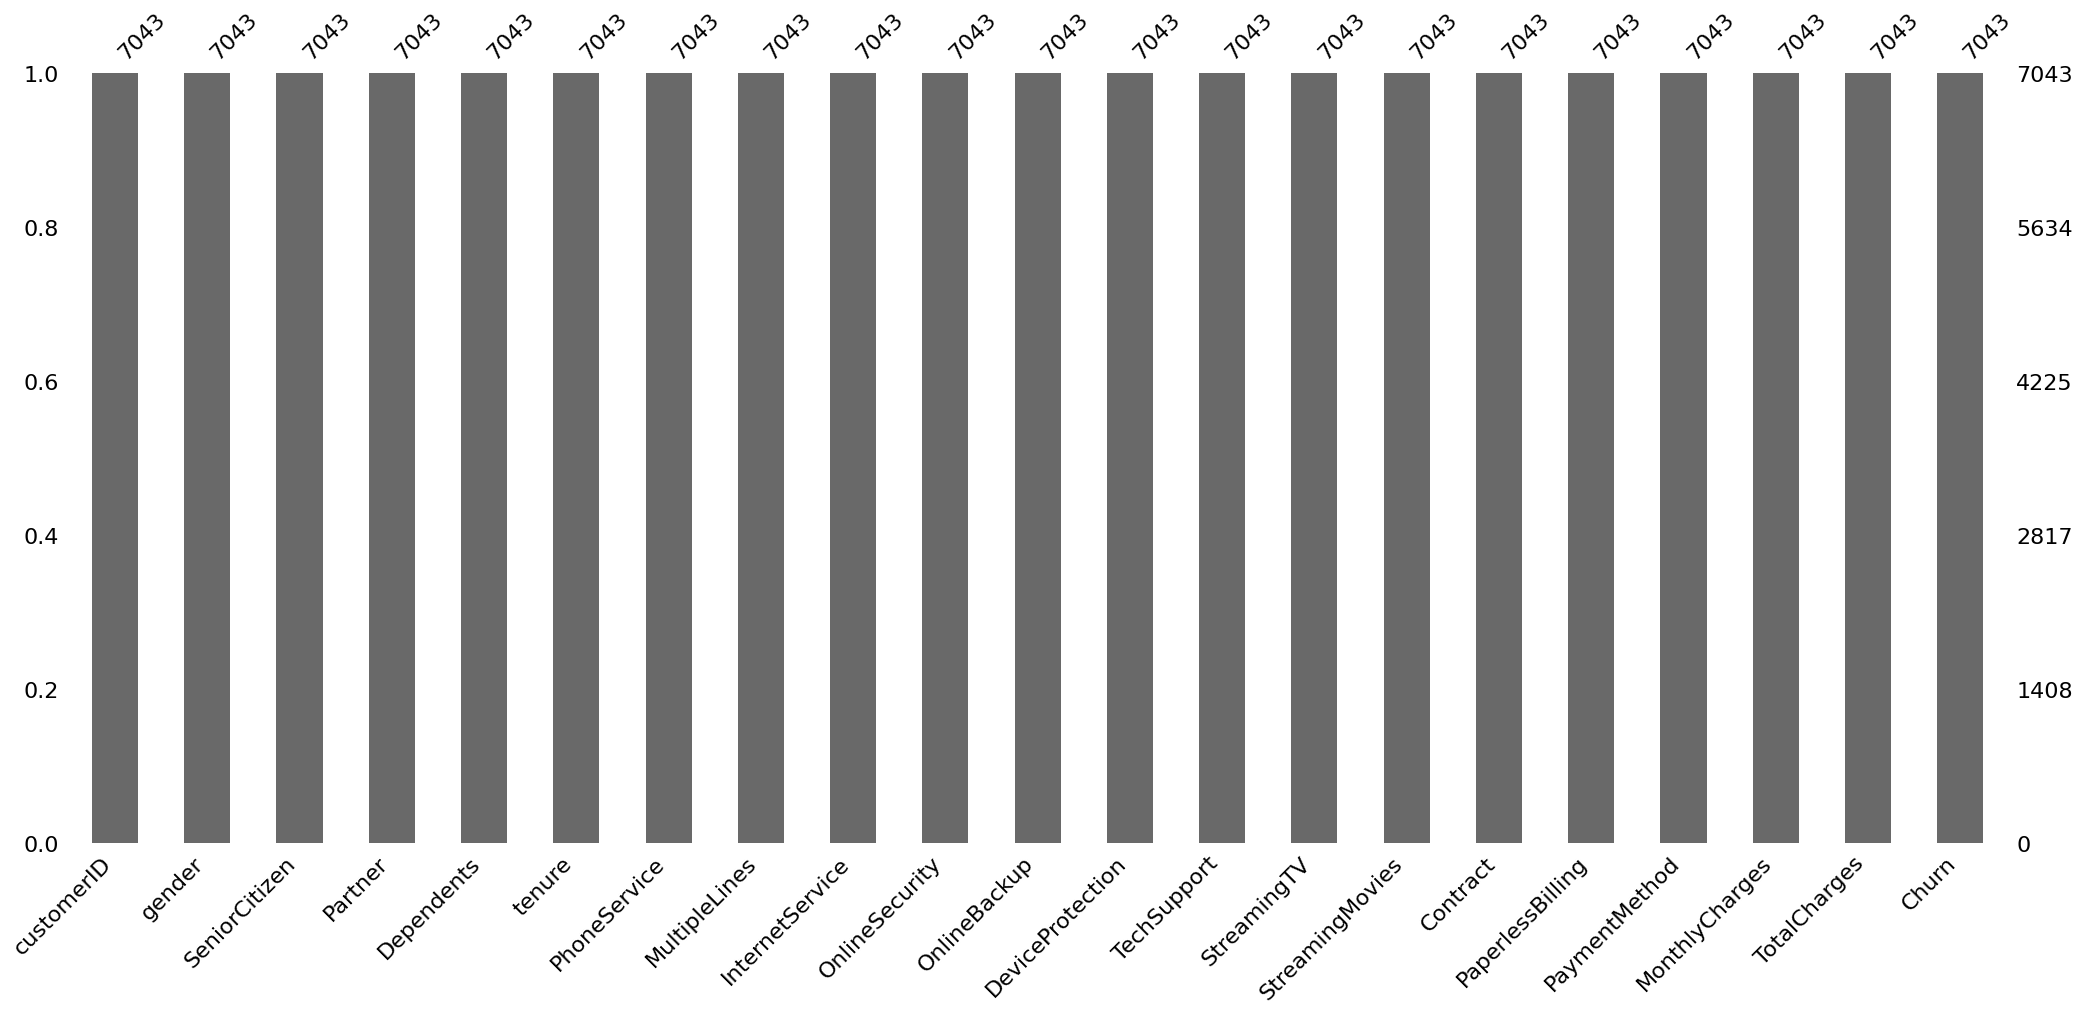

In [9]:
# Visualize to check for null values
plt.figure(figsize=(5, 4))
msno.bar(df)
plt.show()

In [10]:
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [11]:
df.pivot_table(index='gender', columns='Churn', values='customerID', aggfunc='count')

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


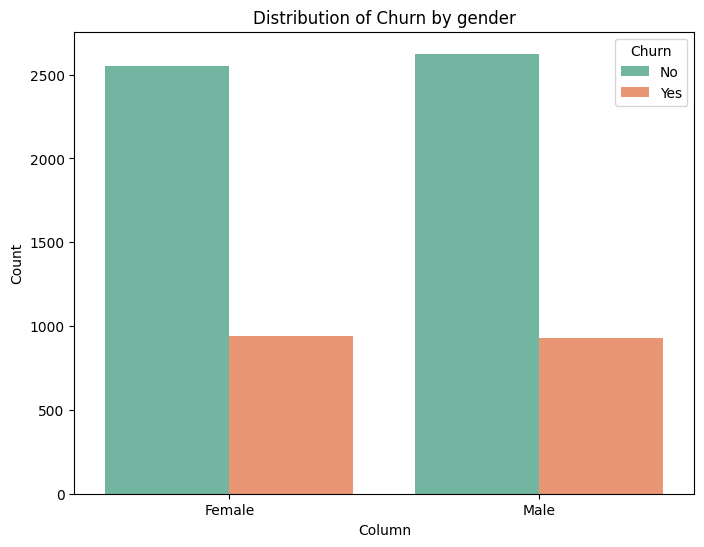

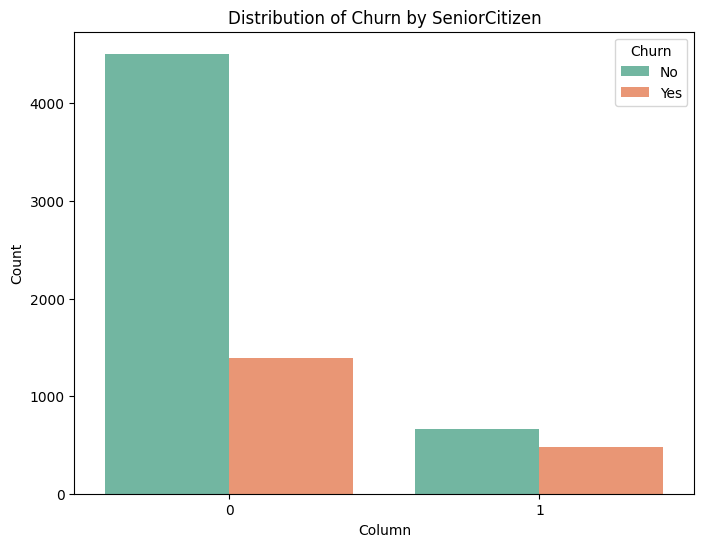

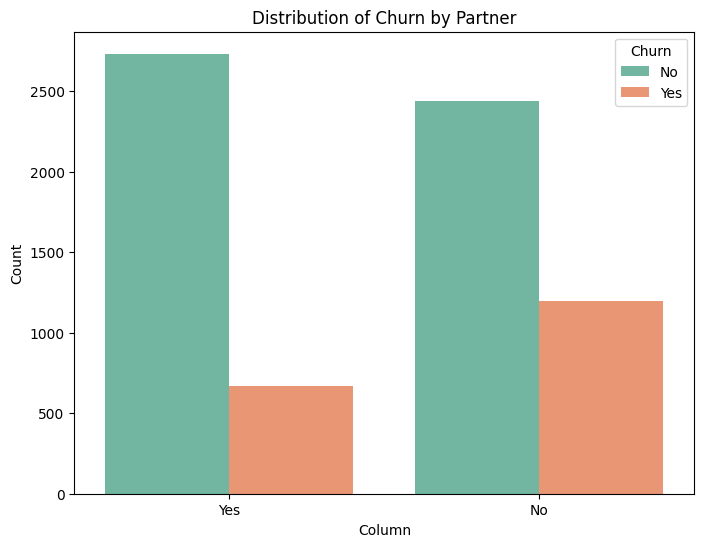

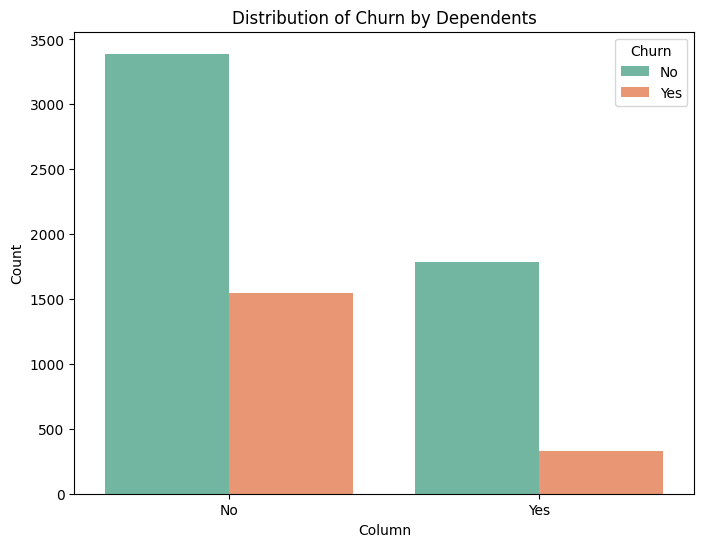

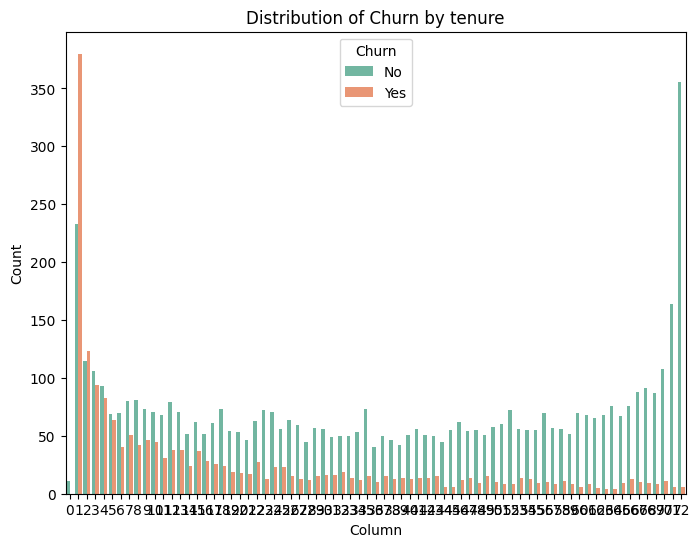

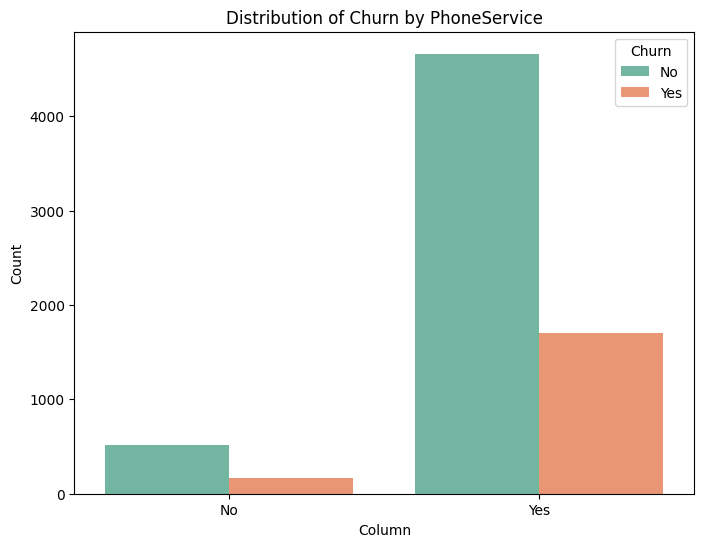

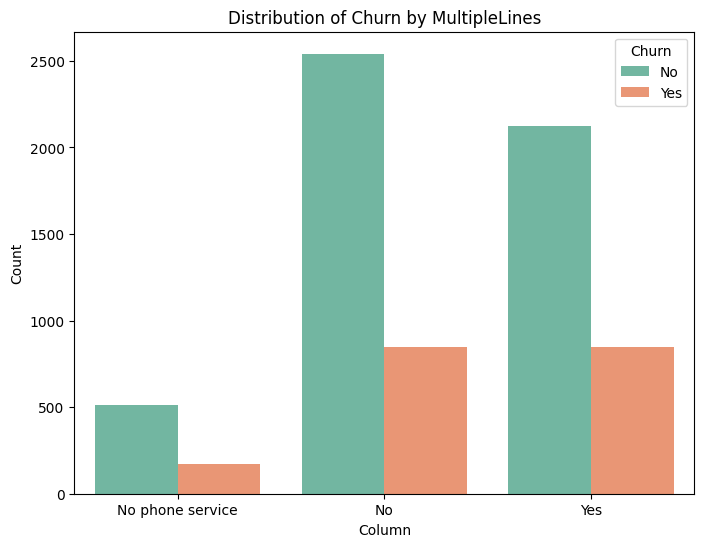

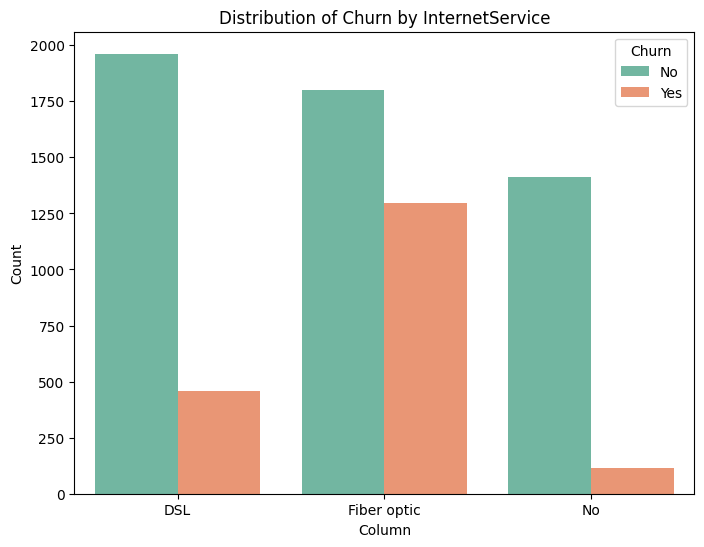

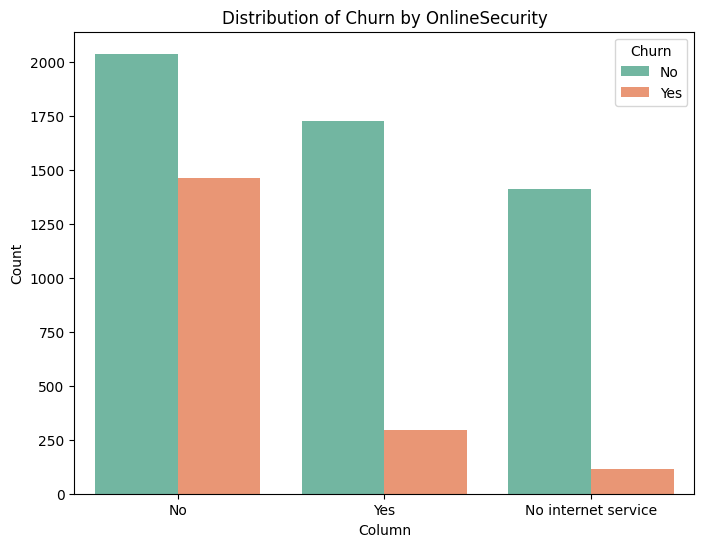

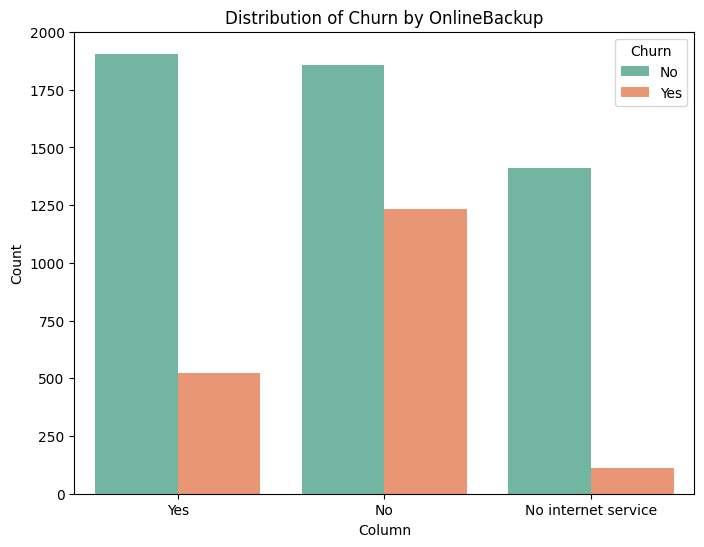

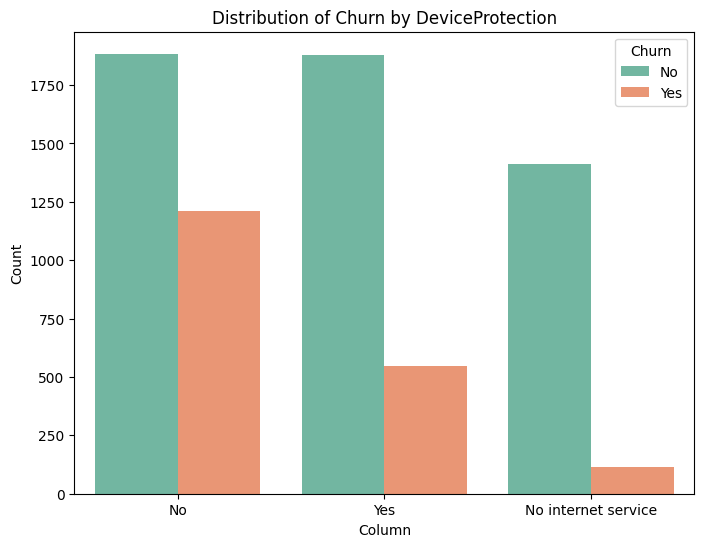

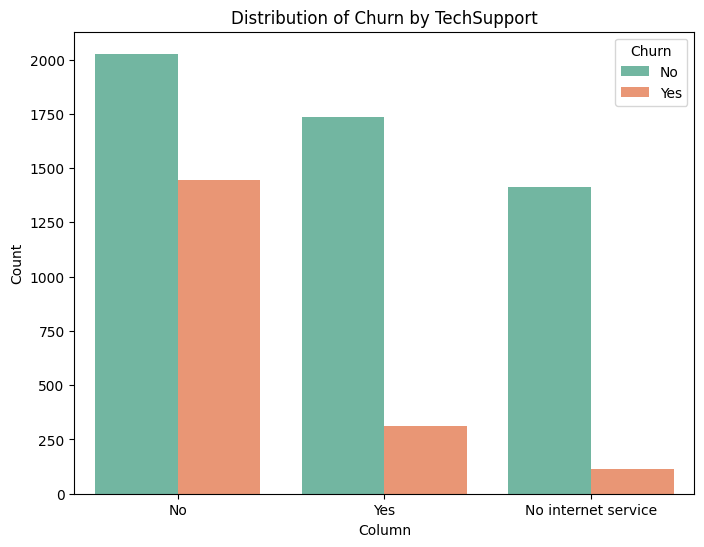

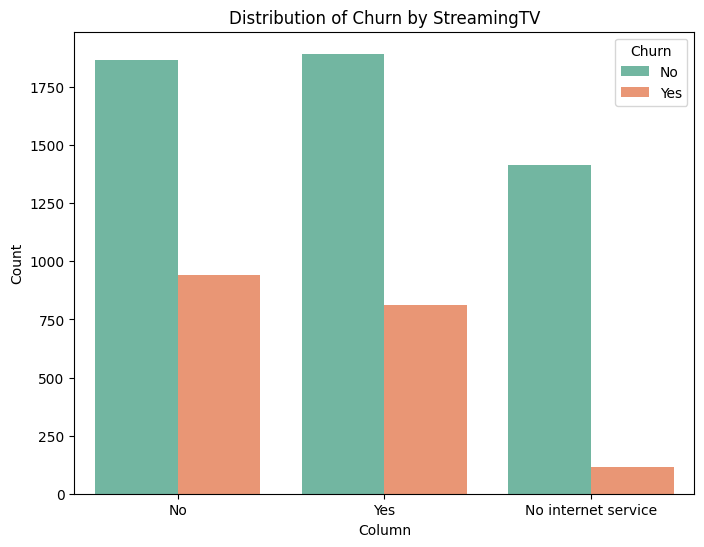

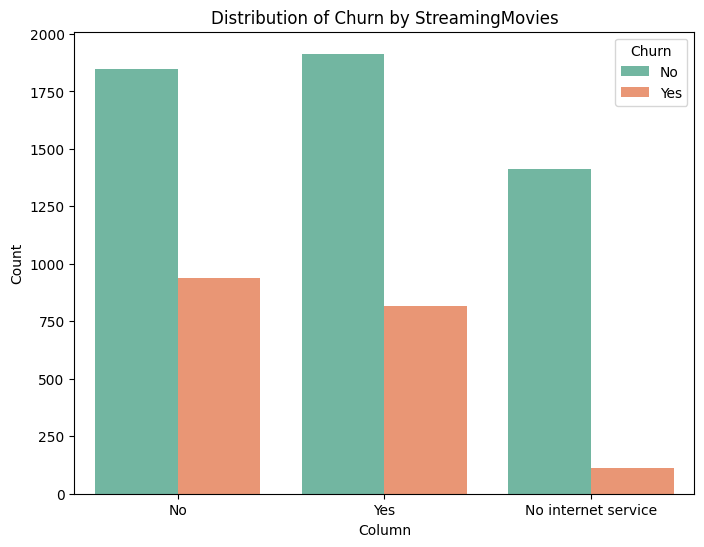

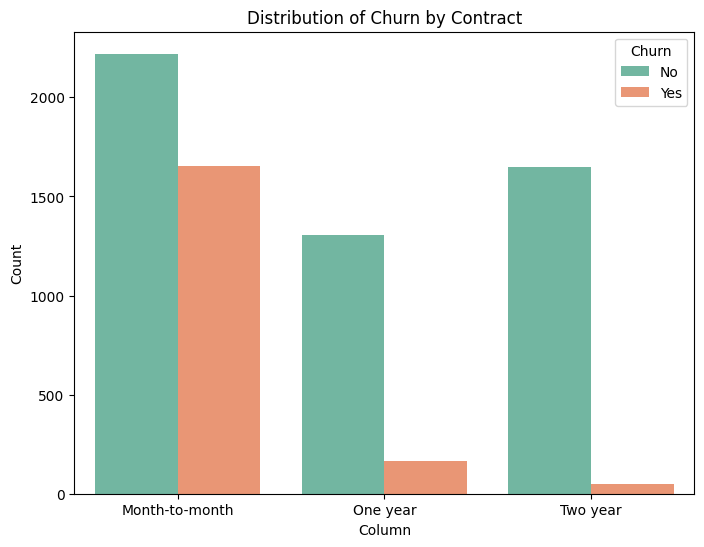

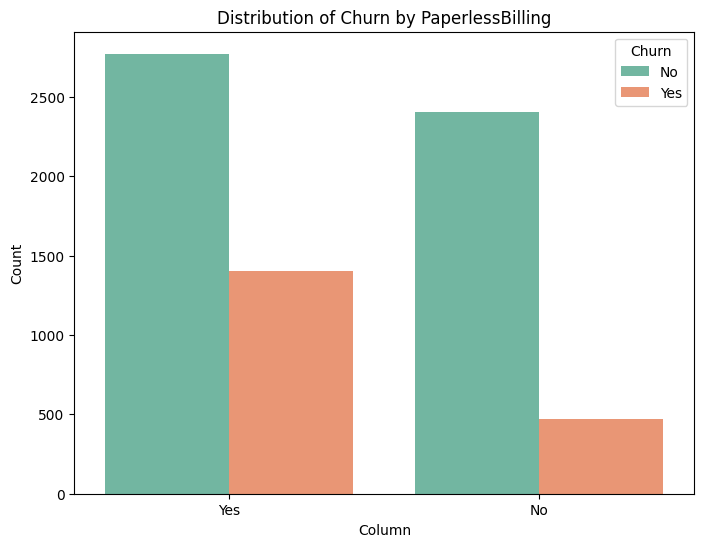

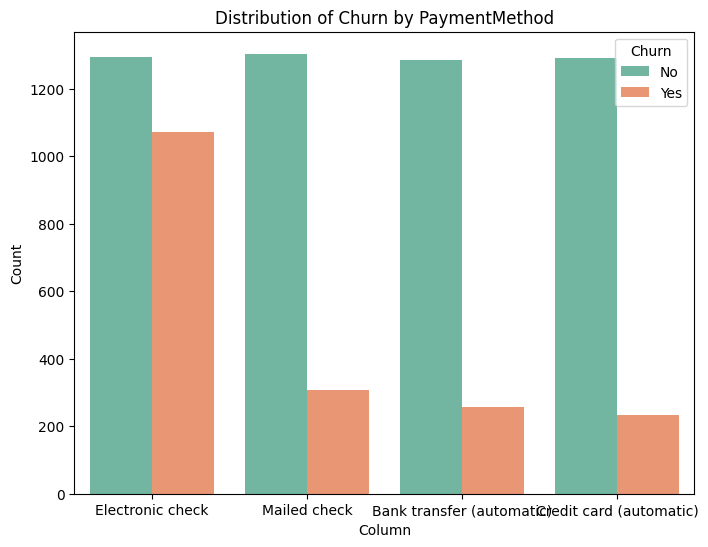

In [12]:
# Get all categorical columns
categorical_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                       'PaymentMethod']

  # Visualizing the categoical columns with their counts
for column in categorical_columns:
  plt.figure(figsize=(8, 6))
  sns.countplot(data=df, x=column, hue='Churn', palette='Set2')
  plt.title(f"Distribution of Churn by {column}")
  plt.xlabel("Column")
  plt.ylabel("Count")
  plt.show()

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
df.groupby('gender')['MonthlyCharges'].mean()

,MonthlyCharges
gender,
Female,65.204243
Male,64.327482


In [15]:
df.groupby('Churn')['customerID'].count()

,customerID
Churn,
No,5174
Yes,1869


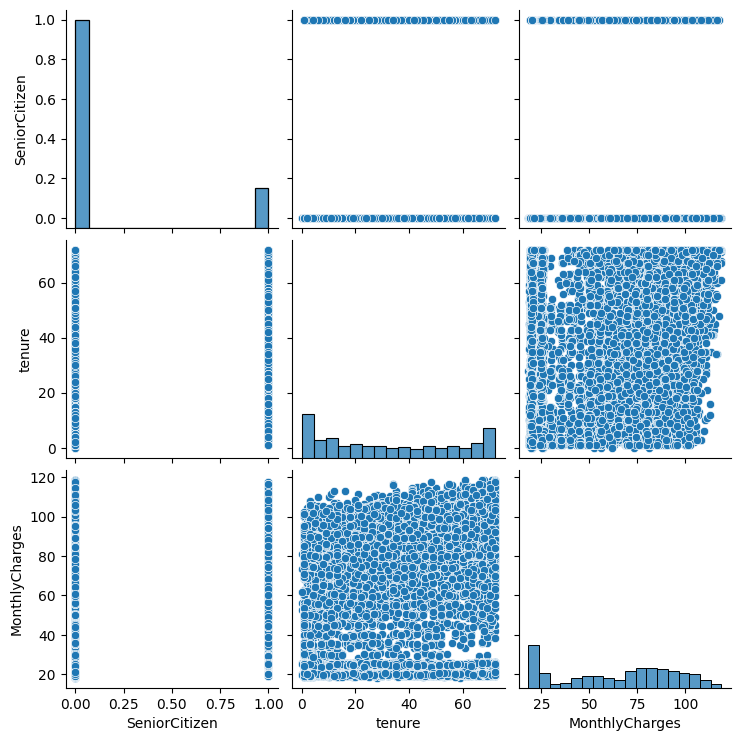

In [16]:
sns.pairplot(df)

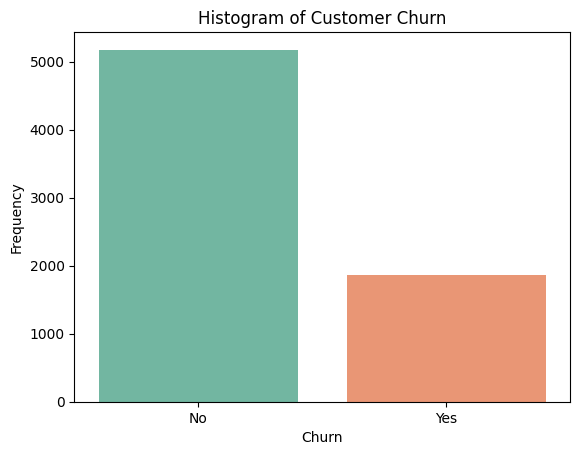

In [17]:
plt.title('Histogram of Customer Churn')
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2')
plt.ylabel('Frequency')
plt.show()

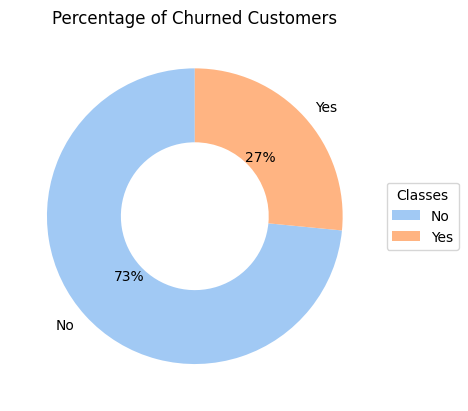

In [18]:
labels = ['No', 'Yes']
data = [(df['Churn'] == 'No').sum(), (df['Churn'] == 'Yes').sum()]
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    data,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct='%.0f%%',
    wedgeprops=dict(width=0.5)
)
plt.title('Percentage of Churned Customers')
ax.legend(wedges, labels, title='Classes', loc='center left', bbox_to_anchor=(1,0,0.5,1))
plt.show()

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df['Partner'].value_counts()

,count
Partner,
No,3641
Yes,3402


In [21]:
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


/tmp/ipython-input-3949240213.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['MonthlyCharges'])


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

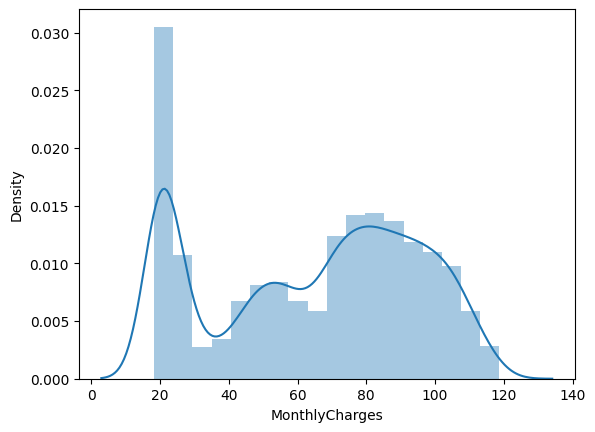

In [22]:
sns.distplot(df['MonthlyCharges'])

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

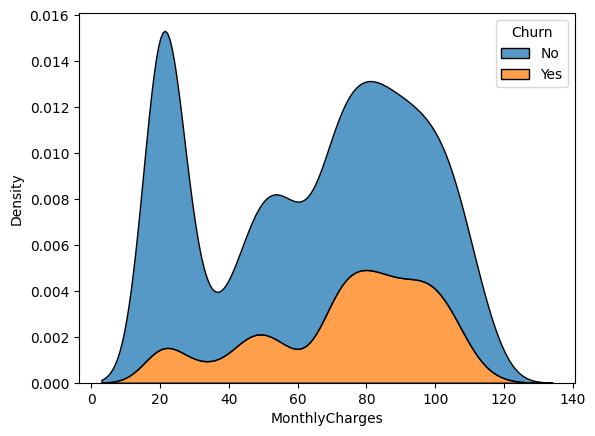

In [25]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack')

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

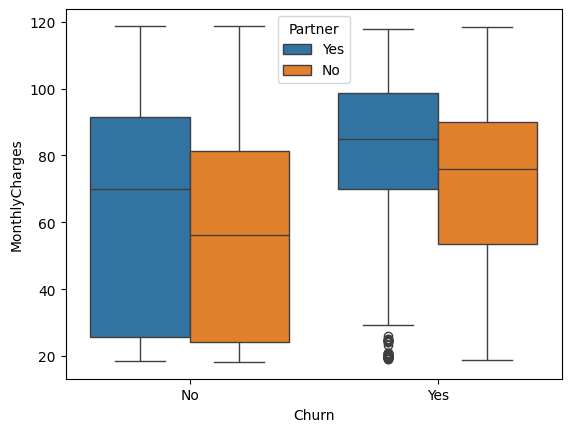

In [32]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Partner')

<Axes: xlabel='Churn', ylabel='Partner'>

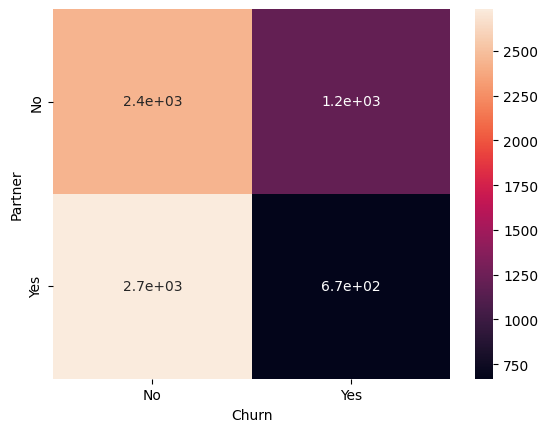

In [35]:
# Heatmaps
sns.heatmap(pd.crosstab(df['Partner'], df['Churn']), annot=True)

<Axes: xlabel='MultipleLines', ylabel='Churn'>

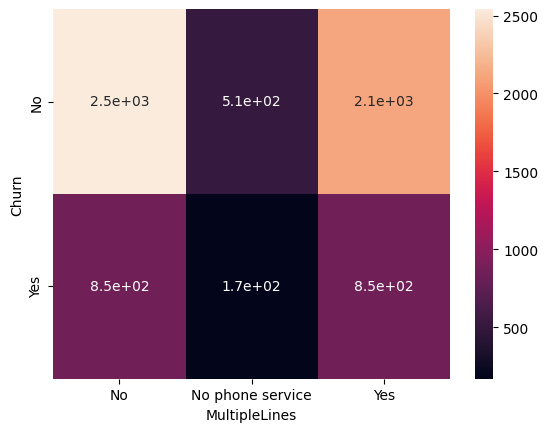

In [39]:
sns.heatmap(pd.crosstab(df['Churn'], df['MultipleLines']), annot=True)

<Axes: xlabel='Churn', ylabel='SeniorCitizen'>

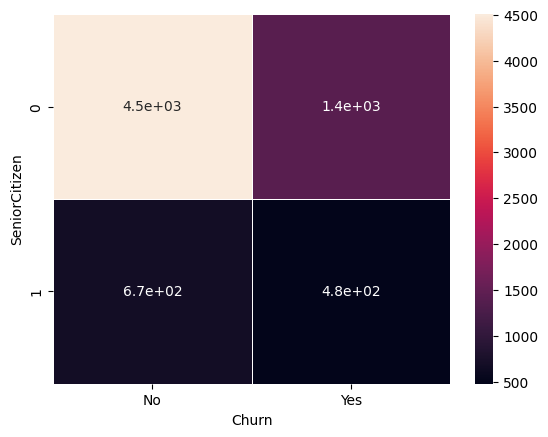

In [80]:
sns.heatmap(pd.crosstab(df['SeniorCitizen'], df['Churn']), annot=True, linewidth=0.5)

<Axes: xlabel='DeviceProtection', ylabel='Churn'>

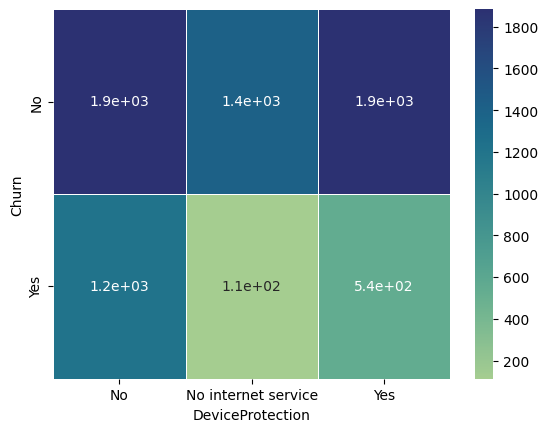

In [78]:
sns.heatmap(pd.crosstab(df['Churn'], df['DeviceProtection']), annot=True, linewidth=0.5)

[]

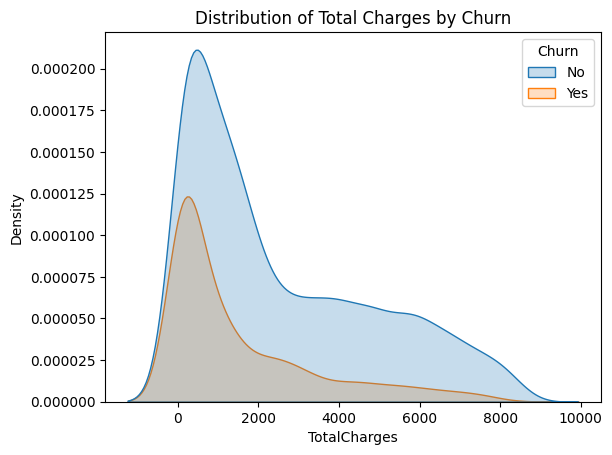

In [65]:
plt.figure()
plt.title("Distribution of Total Charges by Churn")
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True)
plt.plot()

In [58]:
print("Monthly Charges mean:", df['MonthlyCharges'].mean())
print("Monthly Charges median:", df['MonthlyCharges'].median())

Monthly Charges mean: 64.76169246059918
Monthly Charges median: 70.35


In [66]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


[]

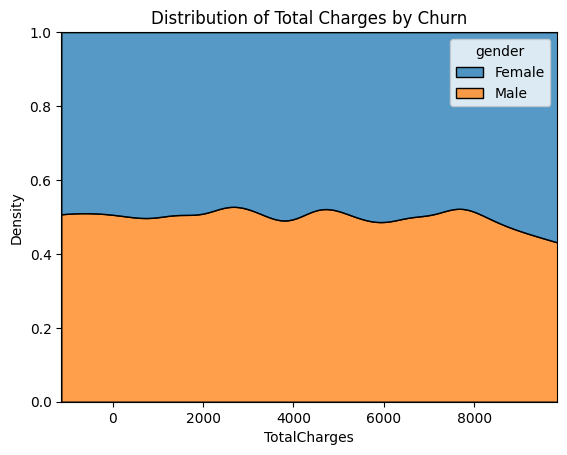

In [70]:
plt.figure()
plt.title("Distribution of Total Charges by Churn")
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')
sns.kdeplot(data=df, x='TotalCharges', hue='gender', fill=True, multiple='fill')
plt.plot()

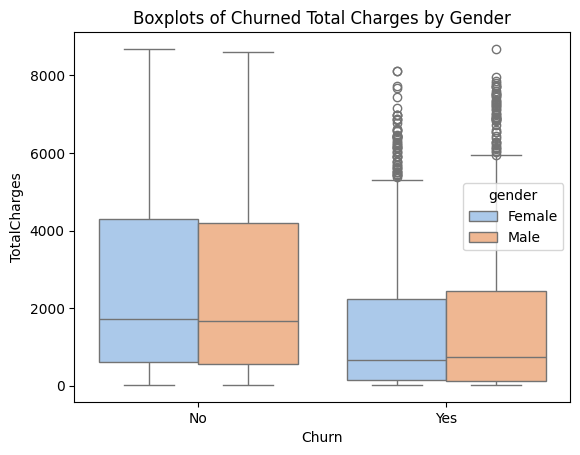

In [77]:
plt.figure()
plt.title('Boxplots of Churned Total Charges by Gender')
sns.set_palette('pastel')
sns.boxplot(data=df, x='Churn', y='TotalCharges', hue='gender')
plt.show()

<Axes: xlabel='TotalCharges', ylabel='Density'>

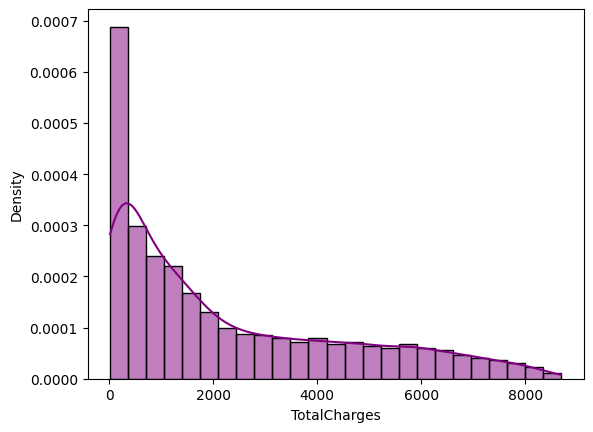

In [105]:
sns.histplot(data=df, x='TotalCharges', kde=True, stat='density', color='purple')

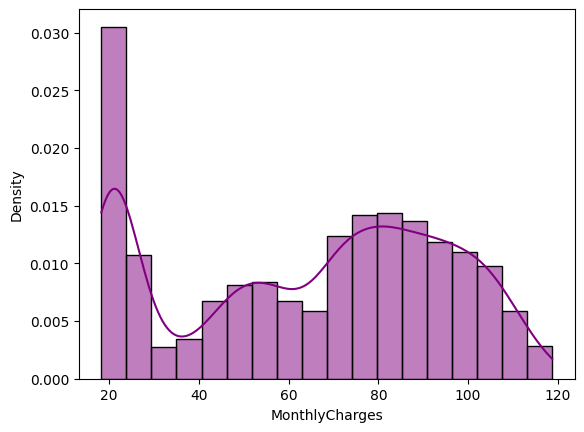

In [106]:
sns.histplot(data=df, x='MonthlyCharges', stat='density', kde=True, color='purple')
plt.show()